<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/lecture_notebooks/lecture%2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# prompt: load the "labeled faces in the wild" dataset

import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import NMF
import numpy as np

In [ ]:


# Load the Labeled Faces in the Wild dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Access the data and target variables
faces = lfw_people.data
target = lfw_people.target

n_samples, dim = faces.shape

print( "Size of one image:", lfw_people.images[0].shape )


In [ ]:
print( "Size of one image:", lfw_people.images[0].shape )


Size of one image: (50, 37)


In [ ]:
X = faces

In [ ]:
X.dtype

dtype('float32')

In [ ]:
Xc = X - np.mean(X, axis=0,keepdims=True)

In [ ]:
np.mean( Xc, axis=0 )

array([-1.97266843e-07,  9.64179208e-08, -7.32100531e-08, ...,
       -1.19232425e-07, -1.25456666e-07, -1.42995615e-08], dtype=float32)

In [ ]:
Sigma = (1/n_samples) * np.dot( Xc.T, Xc )
Sigma_noc = (1/n_samples) * np.dot( X.T, X )

In [ ]:
Sigma.shape

(1850, 1850)

In [ ]:
# calculate the eigenvectors and eigenvalues of Sigma
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
eval_noc, evec_noc = np.linalg.eigh(Sigma_noc)

<ipython-input-40-661a9eb1555d>:3: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(eigenvalues))
<ipython-input-40-661a9eb1555d>:4: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(eval_noc))


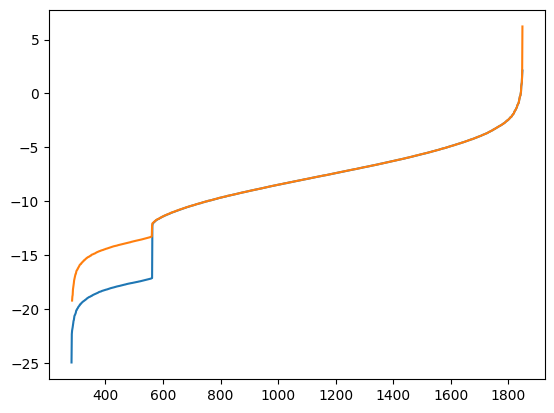

In [ ]:
import matplotlib.pyplot as plt

plt.plot(np.log(eigenvalues))
plt.plot(np.log(eval_noc))

plt.show()

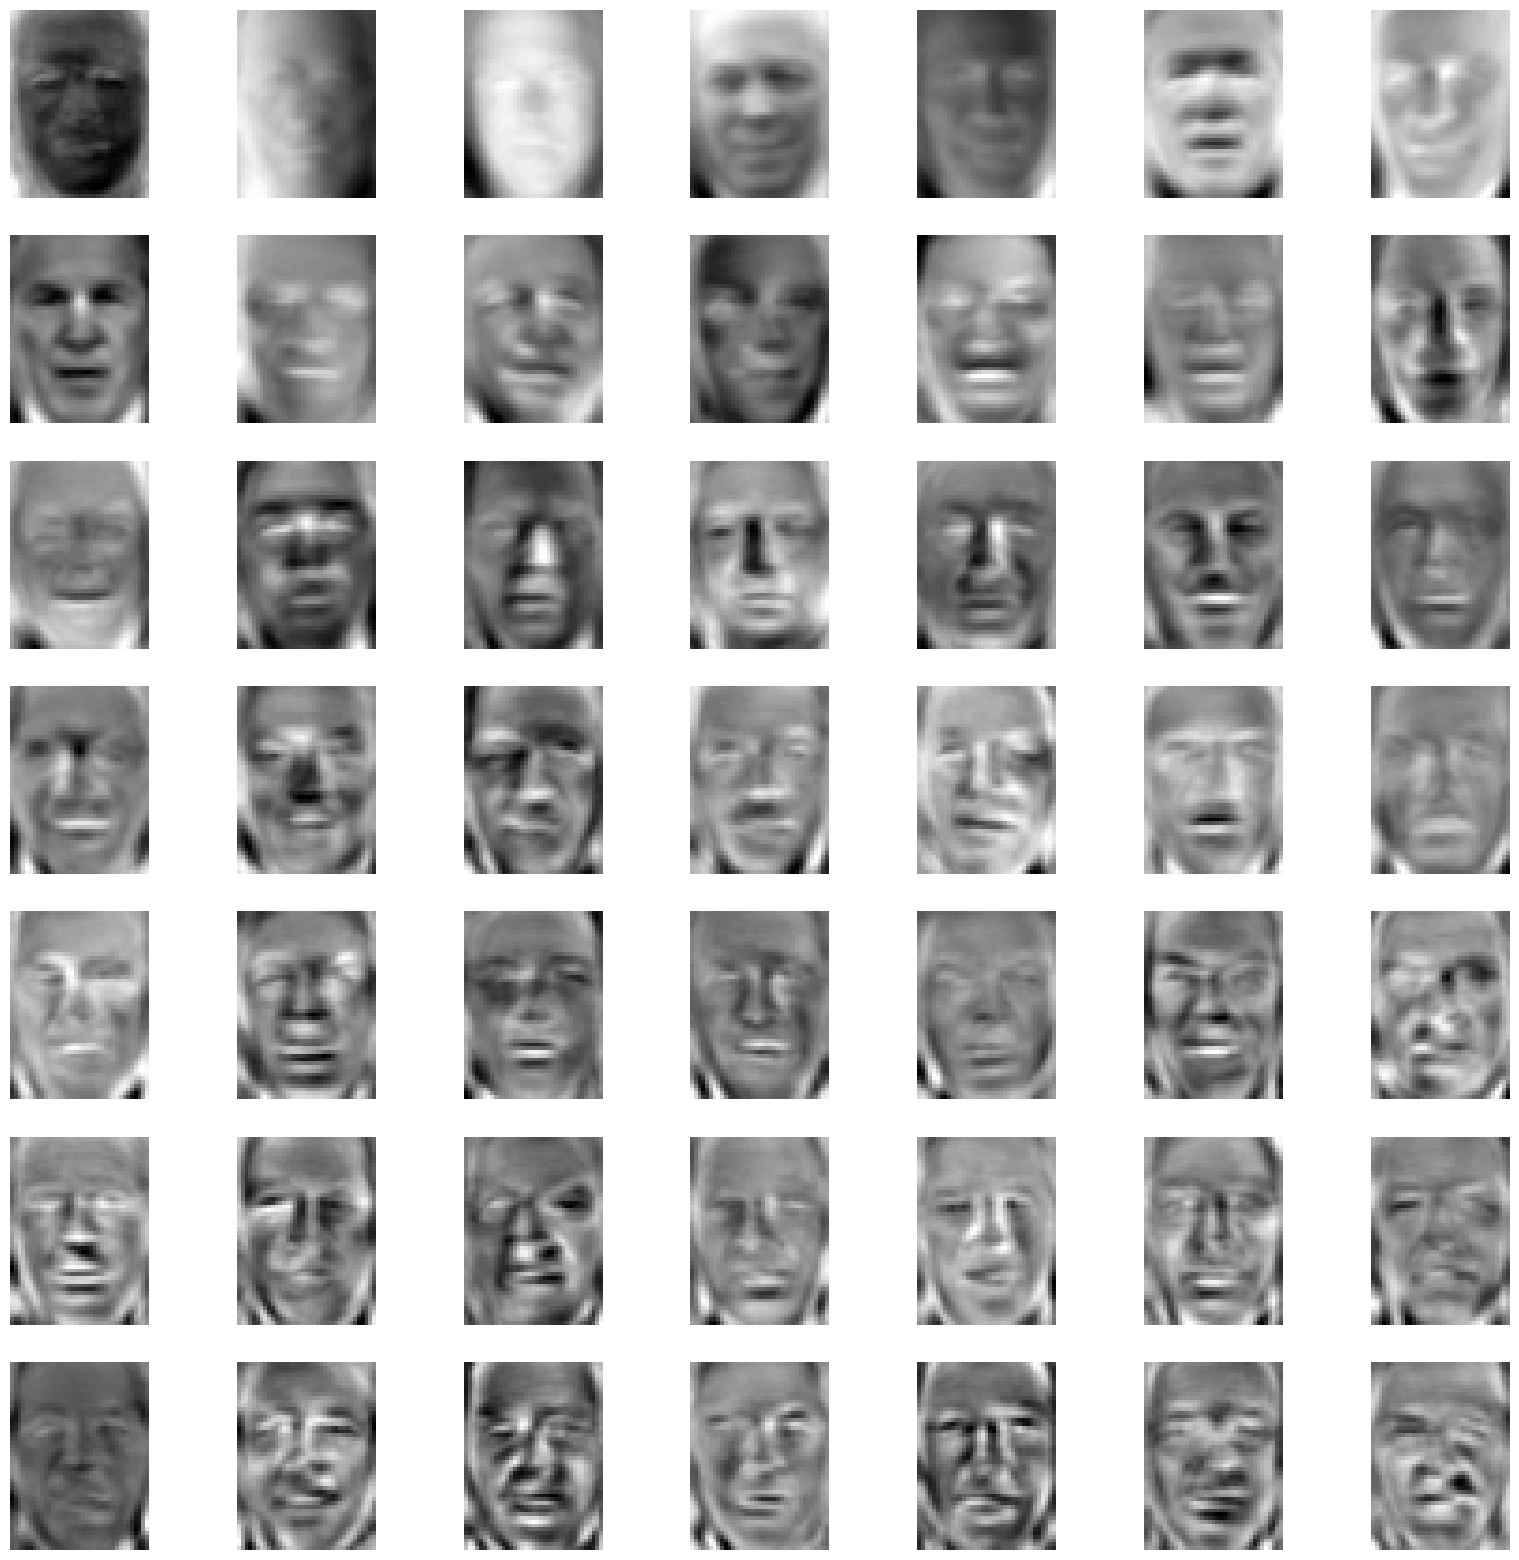

In [ ]:
# Visualize the components
fig, axes = plt.subplots(7, 7, figsize=(20, 20))
for i, ax in enumerate(axes.flat):
    if i < 49:  # Make sure we don't exceed the number of components
        ax.imshow(eigenvectors[:,-(i+1)].reshape(lfw_people.images[0].shape), cmap='gray') # Use image shape from dataset
 #       ax.imshow(evec_noc[:,-(i+1)].reshape(lfw_people.images[0].shape), cmap='gray') # Use image shape from dataset
        ax.axis('off')
    else:
        ax.axis('off')

plt.show()

In [ ]:
eigenvalues[-2]

5.7033215

In [ ]:
W = eigenvectors[:,-1:-501:-1]
print(W.shape)
z = np.dot( W.T, Xc.T )
print(z.shape)

(1850, 500)
(500, 1288)


In [ ]:
reconstructed_faces = np.dot( W, z ) + np.mean(X, axis=0, keepdims=True).T
print(reconstructed_faces.shape)

(1850, 1288)


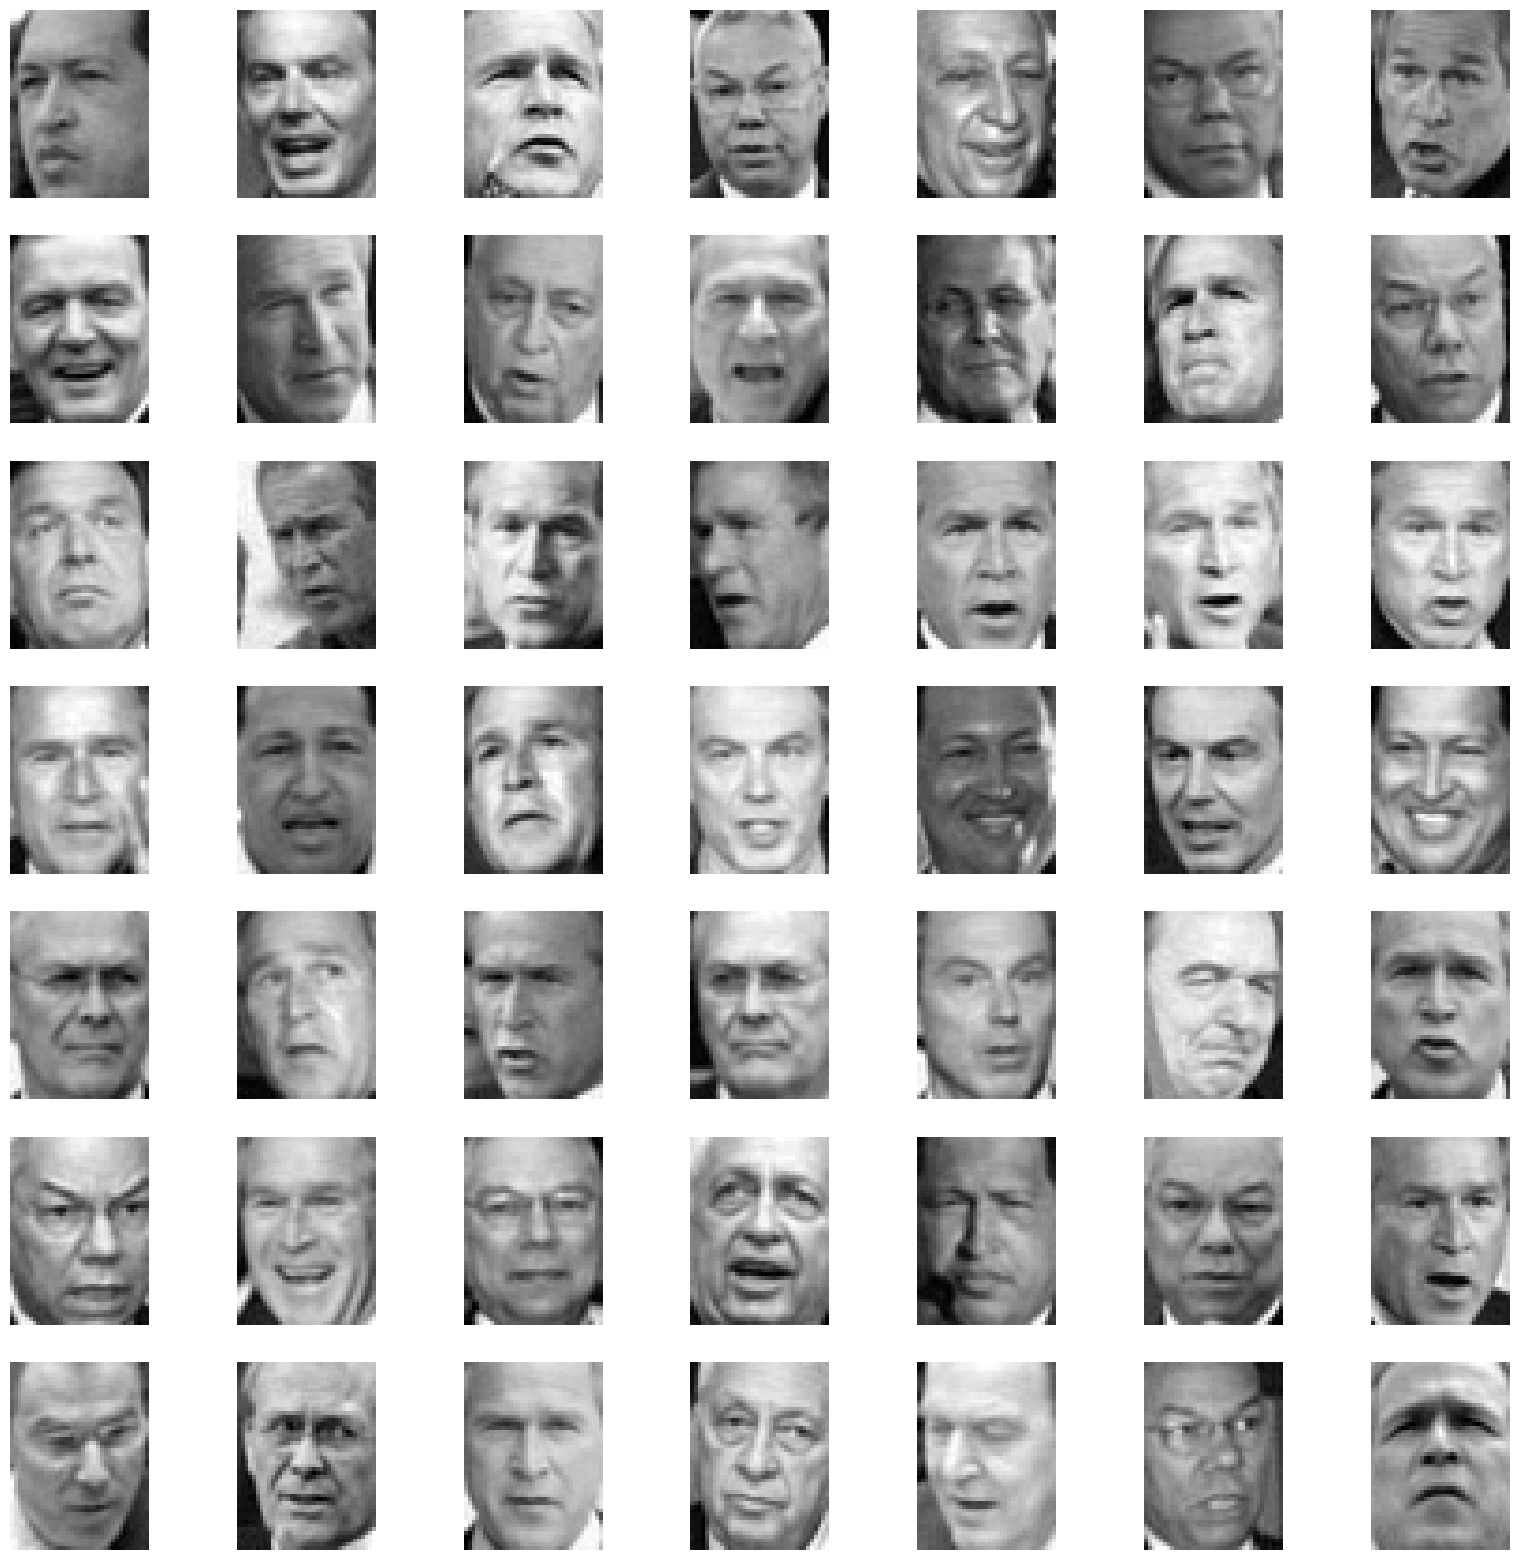

In [ ]:
# Visualize the components
fig, axes = plt.subplots(7, 7, figsize=(20, 20))
for i, ax in enumerate(axes.flat):
    if i < 49:  # Make sure we don't exceed the number of components
        ax.imshow(reconstructed_faces[:,i].reshape(lfw_people.images[0].shape), cmap='gray') # Use image shape from dataset
        ax.axis('off')
    else:
        ax.axis('off')

plt.show()

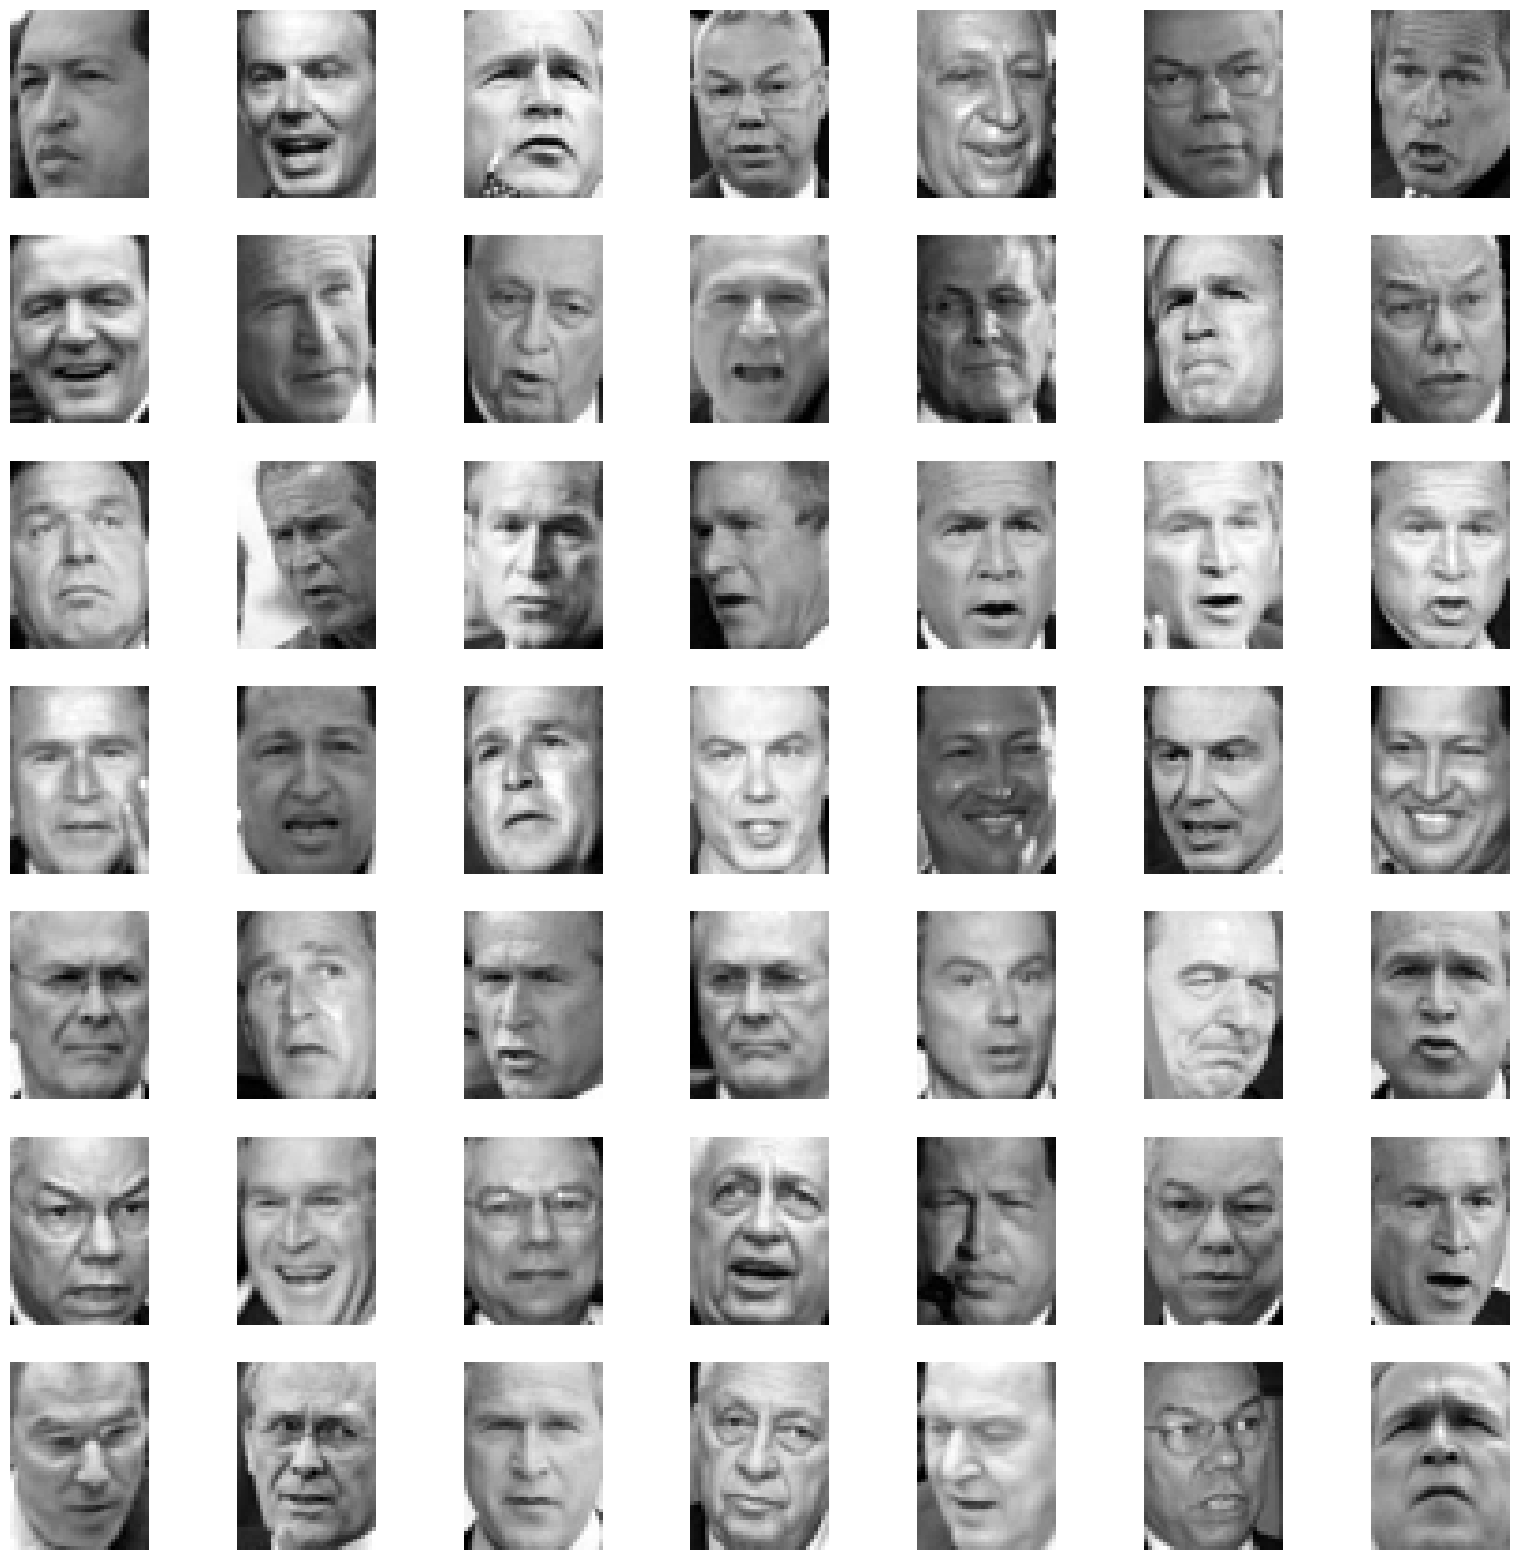

In [ ]:
# Visualize the components
fig, axes = plt.subplots(7, 7, figsize=(20, 20))
for i, ax in enumerate(axes.flat):
    if i < 49:  # Make sure we don't exceed the number of components
        ax.imshow(X[i,:].reshape(lfw_people.images[0].shape), cmap='gray') # Use image shape from dataset
        ax.axis('off')
    else:
        ax.axis('off')

plt.show()

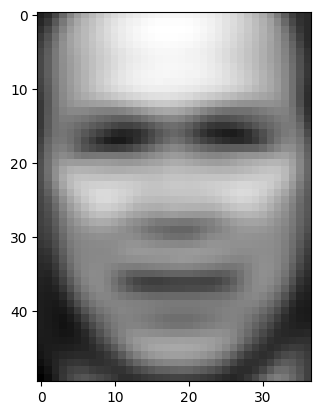

In [ ]:
foo = np.mean(X, axis=0, keepdims=True)

plt.imshow(foo.reshape(lfw_people.images[0].shape), cmap='gray')
#plt.imshow( eigenvectors[:,-1].reshape(lfw_people.images[0].shape), cmap='gray')
plt.show()


In [ ]:
# prompt: calculate the svd of X

U, s, V = np.linalg.svd(X)
np.linalg.svd?



In [ ]:
V.shape
W = V.T[:,0:500]
print(W.shape)
z = np.dot( W.T, X.T )
print(z.shape)

(1850, 500)
(500, 1288)


(1850, 1288)


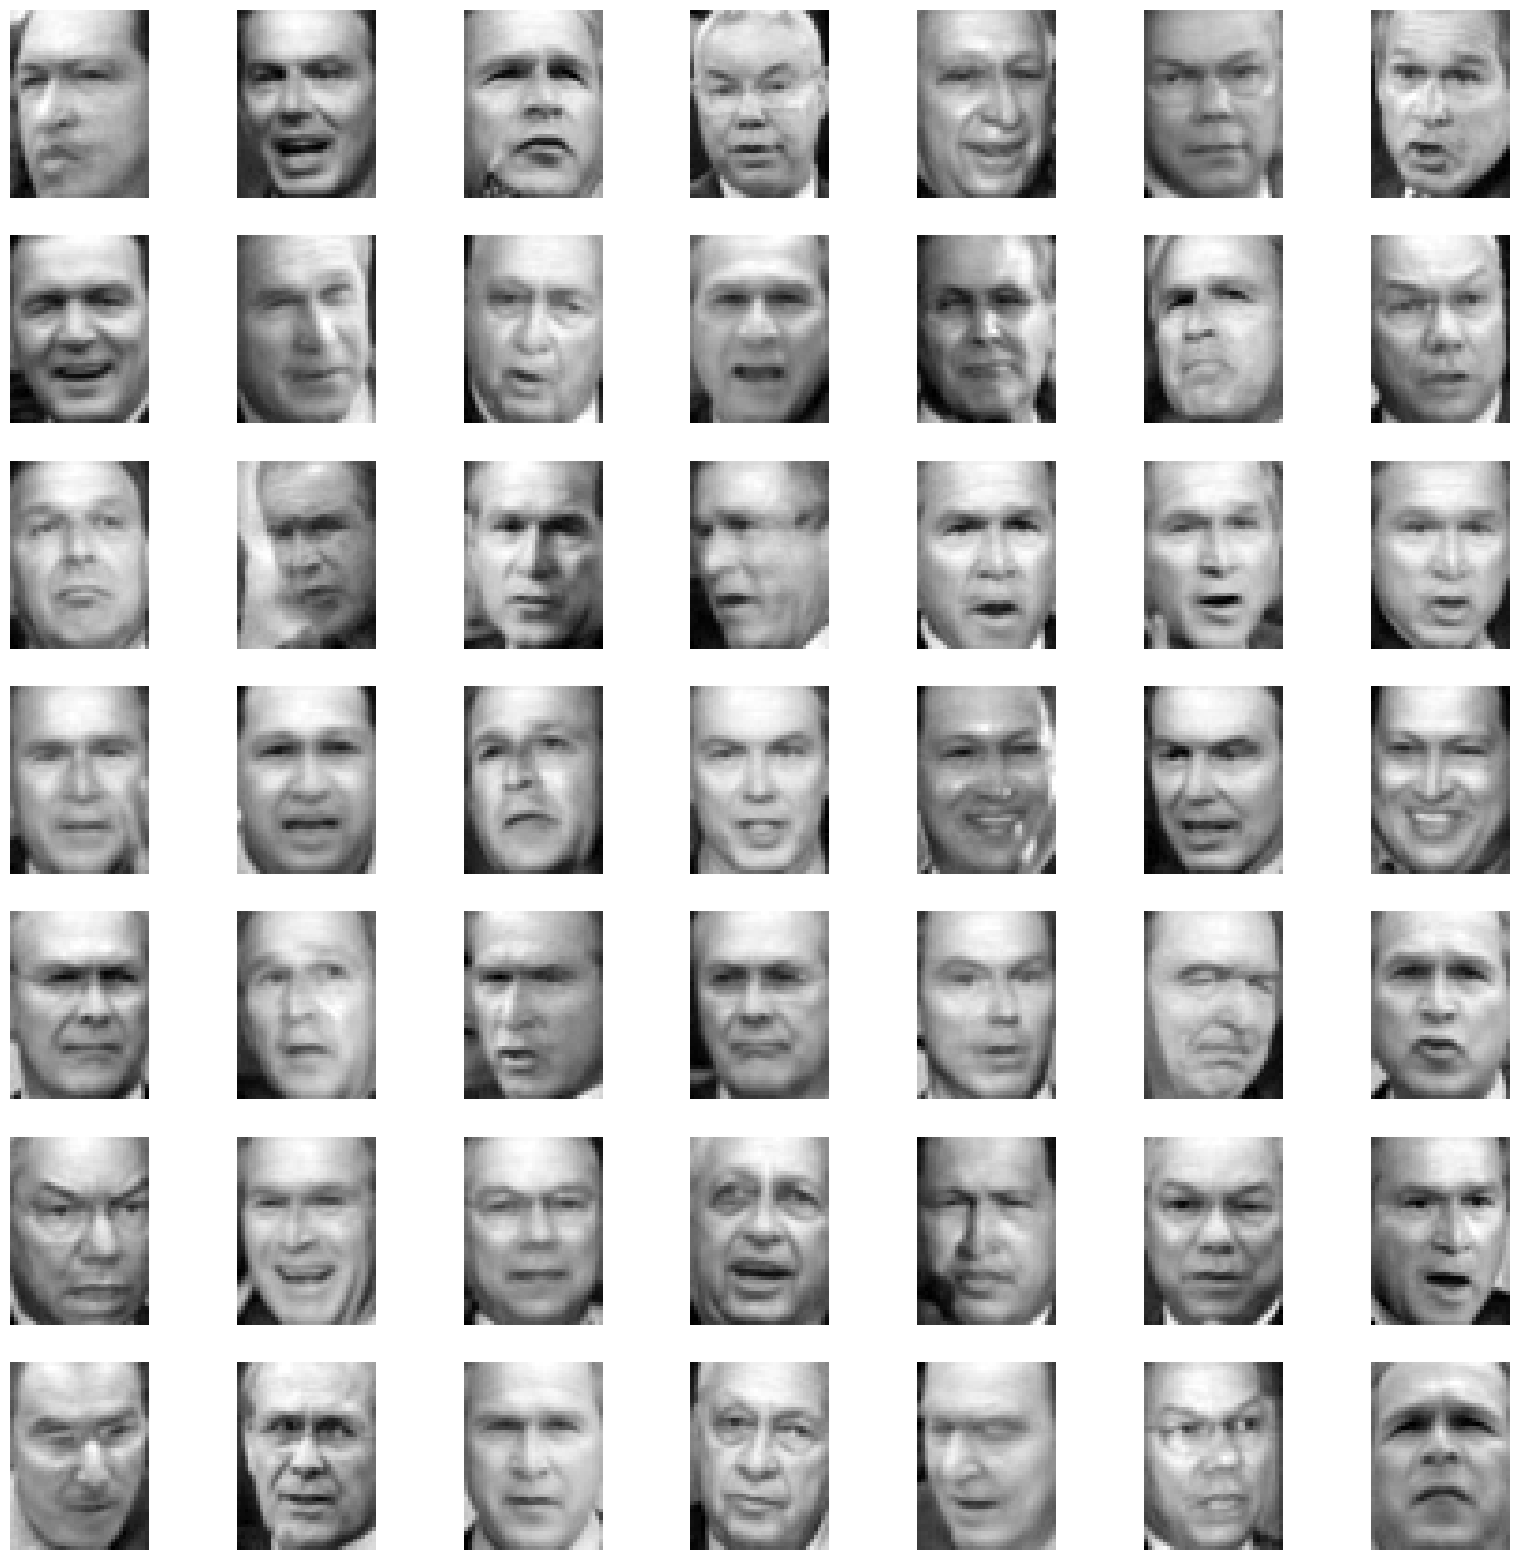

In [ ]:
reconstructed_faces = np.dot( W, z ) + np.mean(X, axis=0, keepdims=True).T
print(reconstructed_faces.shape)
# Visualize the components
fig, axes = plt.subplots(7, 7, figsize=(20, 20))
for i, ax in enumerate(axes.flat):
    if i < 49:  # Make sure we don't exceed the number of components
        ax.imshow(reconstructed_faces[:,i].reshape(lfw_people.images[0].shape), cmap='gray') # Use image shape from dataset
        ax.axis('off')
    else:
        ax.axis('off')

plt.show()

In [ ]:
# Apply NMF
nmf = NMF(n_components=49, random_state=0, max_iter=1000)  # You can adjust the number of components
W = nmf.fit_transform(faces)
H = nmf.components_


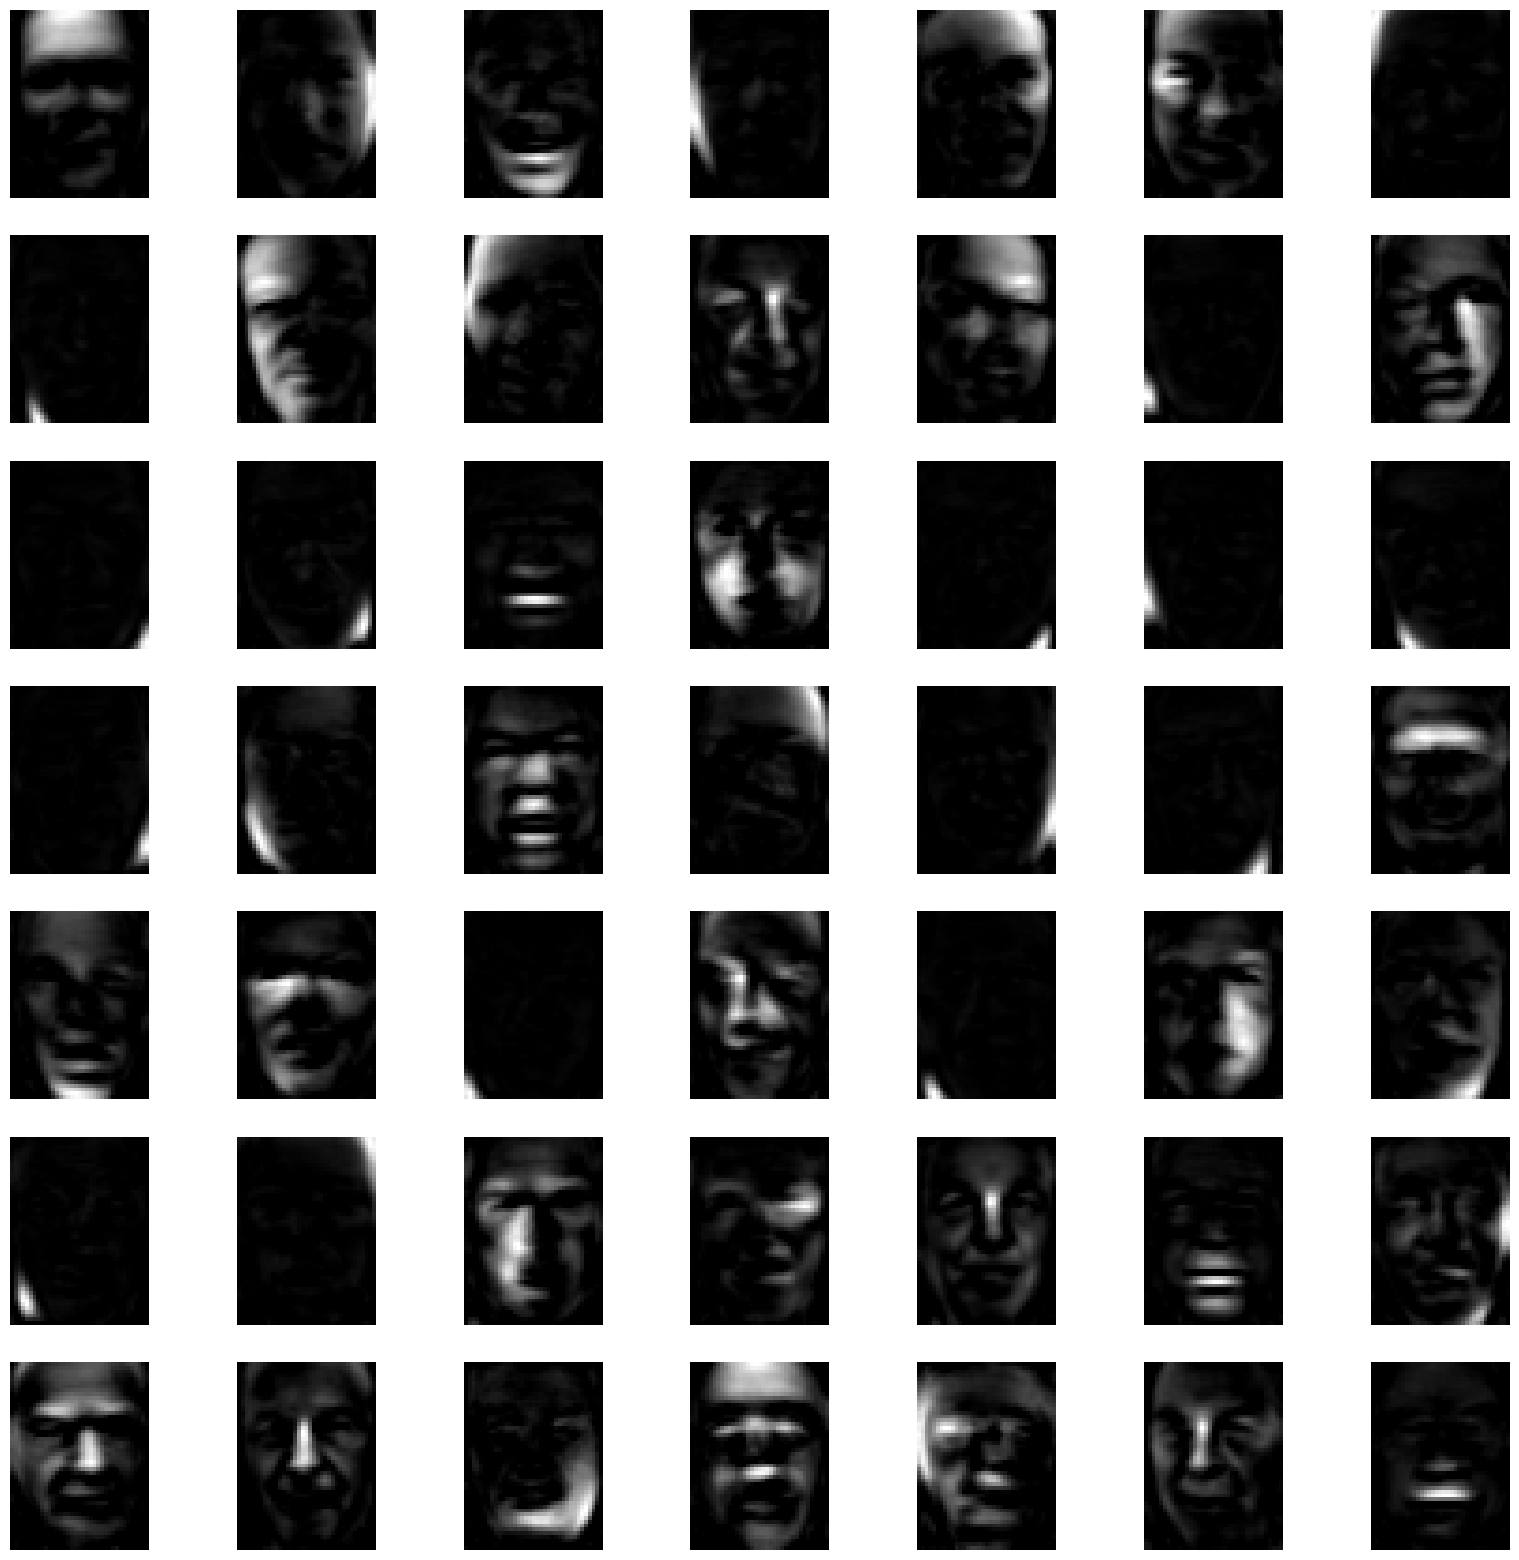

In [ ]:
# Visualize the components
fig, axes = plt.subplots(7, 7, figsize=(20, 20))
for i, ax in enumerate(axes.flat):
    if i < 49:  # Make sure we don't exceed the number of components
        ax.imshow(H[i].reshape(lfw_people.images[0].shape), cmap='gray') # Use image shape from dataset
        ax.axis('off')
    else:
        ax.axis('off')

plt.show()

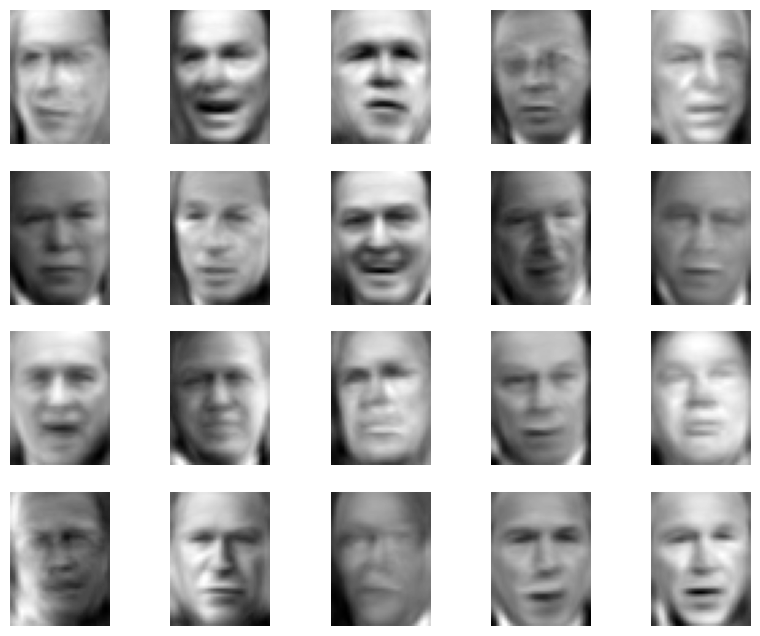

In [ ]:

# Reconstruct faces
reconstructed_faces = nmf.inverse_transform(W)

# Visualize the reconstructed faces
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    if i < 20:
        ax.imshow(reconstructed_faces[i].reshape(lfw_people.images[0].shape), cmap='gray')
        ax.axis('off')
    else:
        ax.axis('off')
plt.show()